### Environment Setup and Dependencies

In [10]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.ndimage as ndimage

import torch
import torch.nn as nn # neural net
import torch.nn.functional as F #activation function
import torch.optim as optim #stochastic gradient
from torch.utils.data import Dataset,DataLoader


def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

set_seed(42)

#configuring device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Pytorch version: {torch.__version__}")
print(f"Device: {device}")



Pytorch version: 2.11.0+cu128
Device: cuda


### Colab Setup for Zip

In [11]:
from google.colab import drive
import zipfile


ZIP_FILE_PATH = '/content/drive/MyDrive/ISBI /archive.zip'
EXTRACT_DIR = '/content/dataset/'

# extracting files
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset Extracted")
print("Extracted files/folders:", os.listdir(EXTRACT_DIR))

Dataset Extracted
Extracted files/folders: ['unmodified-data']


### Dataset Loader

In [12]:
import os
import numpy as np
from PIL import Image
from scipy import ndimage
import torch
from torch.utils.data import Dataset


class ISBI2012Dataset(Dataset):
    """Custom PyTorch Dataset for the ISBI 2012 EM Challenge dataset.

    Loads raw electron microscopy images and ground-truth segmentation masks,
    then pre-computes the spatial weight map w(x) introduced in the U-Net paper.
    """

    def __init__(self, image_path, mask_path, w0=10, sigma=5):
        super().__init__()
        self.w0 = w0
        self.sigma = sigma

        if os.path.isfile(image_path) and image_path.endswith((".tif", ".tiff")):
            self.images = self._load_tiff_stack(image_path)
            self.masks = self._load_tiff_stack(mask_path)
        elif os.path.isdir(image_path):
            image_files = sorted(
                [
                    os.path.join(image_path, f)
                    for f in os.listdir(image_path)
                    if f.endswith((".png", ".tif", ".tiff"))
                ]
            )
            mask_files = sorted(
                [
                    os.path.join(mask_path, f)
                    for f in os.listdir(mask_path)
                    if f.endswith((".png", ".tif", ".tiff"))
                ]
            )
            self.images = [np.array(Image.open(f)) for f in image_files]
            self.masks = [np.array(Image.open(f)) for f in mask_files]
        else:
            raise ValueError(
                f"Invalid path provided: '{image_path}'. Ensure paths point to unzipped files."
            )

    def _load_tiff_stack(self, path):
        """Reads a multi-page TIFF volume stack frame-by-frame into a list of 2D NumPy arrays."""
        img = Image.open(path)
        frames = []
        for i in range(img.n_frames):
            img.seek(i)
            frames.append(np.array(img))
        return frames

    def compute_weight_map(self, mask):
        """Computes the Ronneberger pixel-wise weight map w(x):

        w(x) = wc(x) + w0 * exp(-((d1(x) + d2(x))^2) / (2 * sigma^2))
        """
        cell_mask = (mask > 127).astype(np.uint8)

        freq_cell = np.mean(cell_mask)
        wc = np.where(
            cell_mask == 1,
            1.0 / (freq_cell + 1e-6),
            1.0 / ((1.0 - freq_cell) + 1e-6),
        )
        wc = wc / np.mean(
            wc
        )

        labeled_cells, num_features = ndimage.label(cell_mask)
        if num_features < 2:
            return wc.astype(np.float32)

        distances = np.zeros((num_features, mask.shape[0], mask.shape[1]))
        for i in range(1, num_features + 1):
            distances[i - 1] = ndimage.distance_transform_edt(
                labeled_cells != i
            )

        distances = np.sort(distances, axis=0)
        d1 = distances[0]
        d2 = distances[1]

        weight_map = wc + self.w0 * np.exp(
            -((d1 + d2) ** 2) / (2 * (self.sigma**2))
        )
        return weight_map.astype(np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.float32) / 255.0

        mask = (self.masks[idx].astype(np.float32) / 255.0 > 0.5).astype(
            np.float32
        )

        weight_map = self.compute_weight_map(self.masks[idx])

        image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        weight_tensor = torch.tensor(weight_map, dtype=torch.float32).unsqueeze(
            0
        )

        return image_tensor, mask_tensor, weight_tensor



IMAGE_PATH = "/content/dataset/unmodified-data/train/imgs"
MASK_PATH = "/content/dataset/unmodified-data/train/labels"

if os.path.exists(IMAGE_PATH) and os.path.exists(MASK_PATH):
    dataset = ISBI2012Dataset(IMAGE_PATH, MASK_PATH)
    sample_img, sample_mask, sample_weight = dataset[0]

    print(f"--- Colab Dataset Initialized ---")
    print(f"Total slices in dataset: {len(dataset)}")
    print(f"Image tensor shape     : {sample_img.shape}")
    print(f"Mask tensor shape      : {sample_mask.shape}")
    print(f"Weight tensor shape    : {sample_weight.shape}")
else:
    print(f"Note: Check paths.")

--- Colab Dataset Initialized ---
Total slices in dataset: 30
Image tensor shape     : torch.Size([1, 512, 512])
Mask tensor shape      : torch.Size([1, 512, 512])
Weight tensor shape    : torch.Size([1, 512, 512])


In [13]:
import numpy as np
from scipy import ndimage
import torch
from torch.utils.data import DataLoader

def elastic_transform(image, mask, weight_map, alpha=200, sigma=10):
    """
    Applies random elastic deformations to the image, mask, and weight map simultaneously.
    """
    shape = image.shape

    random_dx = (np.random.rand(*shape) * 2 - 1)
    random_dy = (np.random.rand(*shape) * 2 - 1)

    dx = ndimage.gaussian_filter(random_dx, sigma=sigma, mode="constant", cval=0) * alpha
    dy = ndimage.gaussian_filter(random_dy, sigma=sigma, mode="constant", cval=0) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    distorted_image = ndimage.map_coordinates(image, indices, order=3, mode='reflect').reshape(shape)
    distorted_mask = ndimage.map_coordinates(mask, indices, order=0, mode='reflect').reshape(shape)
    distorted_weight = ndimage.map_coordinates(weight_map, indices, order=1, mode='reflect').reshape(shape)

    return distorted_image, distorted_mask, distorted_weight

def random_augmentations(image, mask, weight_map):
    """
    Applies random horizontal flips, vertical flips, and 90-degree rotations.
    """
    if np.random.rand() > 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)
        weight_map = np.fliplr(weight_map)

    if np.random.rand() > 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)
        weight_map = np.flipud(weight_map)

    k = np.random.randint(0, 4)
    if k > 0:
        image = np.rot90(image, k)
        mask = np.rot90(mask, k)
        weight_map = np.rot90(weight_map, k)

    return image, mask, weight_map

class AugmentedISBI2012Dataset(ISBI2012Dataset):
    """
    Subclasses ISBI2012Dataset to apply on-the-fly elastic deformations
    and rigid transformations during training.
    """
    def __init__(self, image_path, mask_path, augment=True, w0=10, sigma=5):
        super().__init__(image_path, mask_path, w0=w0, sigma=sigma)
        self.augment = augment

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.float32) / 255.0
        mask = (self.masks[idx].astype(np.float32) / 255.0 > 0.5).astype(np.float32)
        weight_map = self.compute_weight_map(self.masks[idx])

        if self.augment:
            image, mask, weight_map = elastic_transform(image, mask, weight_map, alpha=200, sigma=10)
            image, mask, weight_map = random_augmentations(image, mask, weight_map)

        image = np.ascontiguousarray(image)
        mask = np.ascontiguousarray(mask)
        weight_map = np.ascontiguousarray(weight_map)

        image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        weight_tensor = torch.tensor(weight_map, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor, weight_tensor


train_dataset = AugmentedISBI2012Dataset(IMAGE_PATH, MASK_PATH, augment=True)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"--- DataLoader Initialized ---")
print(f"Total mini-batches per epoch: {len(train_loader)}")

--- DataLoader Initialized ---
Total mini-batches per epoch: 30


In [14]:


class DoubleConv(nn.Module):
    """
    Double Convolution Block: Applies two consecutive 3x3 convolutions,
    each followed by Batch Normalization and a ReLU activation function.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class DownBlock(nn.Module):
    """
    Contracting Block (Encoder Step): Downsamples spatial dimensions by 2x
    using 2x2 Max Pooling, then applies DoubleConv to double the feature channel depth.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class UpBlock(nn.Module):
    """
    Expansive Block (Decoder Step): Upsamples feature maps using 2x2 Transposed
    Convolution (Up-Conv), concatenates high-resolution skip features from the encoder,
    and applies DoubleConv.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)
        if diffY != 0 or diffX != 0:
            x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    """
    Full 2D U-Net Architecture (Ronneberger et al., 2015).
    Symmetric 4-level Encoder-Decoder architecture with skip connections.
    """
    def __init__(self, in_channels=1, num_classes=1, init_features=64):
        super(UNet, self).__init__()
        f = init_features

        self.inc = DoubleConv(in_channels, f)      # 1 -> 64 channels
        self.down1 = DownBlock(f, f * 2)            # 64 -> 128 channels
        self.down2 = DownBlock(f * 2, f * 4)        # 128 -> 256 channels
        self.down3 = DownBlock(f * 4, f * 8)        # 256 -> 512 channels

        self.down4 = DownBlock(f * 8, f * 16)       # 512 -> 1024 channels

        self.up1 = UpBlock(f * 16, f * 8)           # 1024 -> 512 channels
        self.up2 = UpBlock(f * 8, f * 4)            # 512 -> 256 channels
        self.up3 = UpBlock(f * 4, f * 2)            # 256 -> 128 channels
        self.up4 = UpBlock(f * 2, f)                # 128 -> 64 channels

        self.outc = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, num_classes=1).to(device)

test_input = torch.randn(1, 1, 512, 512).to(device)
test_output = model(test_input)

print(f"--- U-Net Model Initialized ---")
print(f"Input tensor shape     : {test_input.shape}")
print(f"Output tensor shape    : {test_output.shape}")
print(f"Total model parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

--- U-Net Model Initialized ---
Input tensor shape     : torch.Size([1, 1, 512, 512])
Output tensor shape    : torch.Size([1, 1, 512, 512])
Total model parameters : 31,036,481


In [17]:

import torch
import torch.nn as nn
import torch.nn.functional as F


class WeightedBCELoss(nn.Module):
    """Computes the Ronneberger Weighted Binary Cross-Entropy Loss.

    Multiplies the per-pixel binary cross-entropy by the pre-computed spatial
    weight map w(x) to heavily penalize errors along cell boundaries.
    """

    def __init__(self):
        super().__init__()

    def forward(self, logits, targets, weight_maps):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        weighted_bce = bce_loss * weight_maps

        return torch.mean(weighted_bce)


class DiceLoss(nn.Module):
    """Soft Dice Loss for binary image segmentation (Milletari et al., V-Net).

    Measures spatial overlap directly and resists severe class imbalances.
    """

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2.0 * intersection + self.smooth) / (
            probs_flat.sum() + targets_flat.sum() + self.smooth
        )

        return 1.0 - dice_score


class CombinedUNetLoss(nn.Module):
    """Combines Ronneberger Weighted BCE Loss with Soft Dice Loss:

    Loss = Weighted_BCE + Dice_Loss
    """

    def __init__(self, alpha=1.0, beta=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.weighted_bce = WeightedBCELoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets, weight_maps):
        loss_bce = self.weighted_bce(logits, targets, weight_maps)
        loss_dice = self.dice(logits, targets)
        return self.alpha * loss_bce + self.beta * loss_dice


def calculate_iou(logits, targets, threshold=0.5):
    """Calculates the Intersection over Union (IoU / Jaccard Index) metric:

    IoU = True_Positives / (True_Positives + False_Positives + False_Negatives)
    """
    with torch.no_grad():
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        preds_flat = preds.view(-1)
        targets_flat = targets.view(-1)

        intersection = (preds_flat * targets_flat).sum()
        total_union = preds_flat.sum() + targets_flat.sum() - intersection

        if total_union == 0:
            return 1.0

        iou = intersection / (total_union + 1e-6)
        return iou.item()


criterion = CombinedUNetLoss(alpha=1.0, beta=1.0)

dummy_logits = torch.randn(1, 1, 512, 512).to(device)
dummy_targets = torch.randint(0, 2, (1, 1, 512, 512)).float().to(device)
dummy_weights = torch.ones(1, 1, 512, 512).float().to(device)

dummy_loss = criterion(dummy_logits, dummy_targets, dummy_weights)
dummy_iou = calculate_iou(dummy_logits, dummy_targets)

print(f"--- Loss & Evaluation Metrics Initialized ---")
print(f"Sample Combined Loss: {dummy_loss.item():.4f}")
print(f"Sample IoU Score    : {dummy_iou:.4f}")

--- Loss & Evaluation Metrics Initialized ---
Sample Combined Loss: 1.3036
Sample IoU Score    : 0.3346


In [18]:


import torch
import torch.nn as nn
import torch.optim as optim

def initialize_weights(model):
    """
    Applies He (Kaiming) Normal Initialization to all Conv2d and ConvTranspose2d layers.
    Follows Ronneberger et al. (U-Net paper): weights are drawn from a Gaussian
    distribution with standard deviation sqrt(2 / N), where N is the number of
    incoming nodes per neuron (e.g., N = 3x3x64 = 576).
    """
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1.0)
            nn.init.constant_(m.bias, 0.0)

model.apply(initialize_weights)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,         # Base learning rate
    momentum=0.99,   # High momentum to aggregate updates across single-image batches
    weight_decay=1e-4 # L2 regularization penalty
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print("--- Weight Initialization & Optimizer Configured ---")
print(f"Weight Initialization : He / Kaiming Normal (std = sqrt(2/N))")
print(f"Optimizer             : SGD (lr=0.01, momentum=0.99, weight_decay=1e-4)")
print(f"LR Scheduler          : StepLR (step_size=10, gamma=0.1)")

--- Weight Initialization & Optimizer Configured ---
Weight Initialization : He / Kaiming Normal (std = sqrt(2/N))
Optimizer             : SGD (lr=0.01, momentum=0.99, weight_decay=1e-4)
LR Scheduler          : StepLR (step_size=10, gamma=0.1)


In [19]:

import time
import torch

def train_unet(model, train_loader, criterion, optimizer, scheduler, num_epochs=10):
    """
    Executes the training loop over a specified number of epochs.
    Tracks average loss and IoU performance per epoch.
    """
    history = {'train_loss': [], 'train_iou': []}
    print(f"Starting U-Net training on {device} for {num_epochs} epochs...\n")

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        running_iou = 0.0

        for batch_idx, (images, targets, weight_maps) in enumerate(train_loader):
            images = images.to(device)
            targets = targets.to(device)
            weight_maps = weight_maps.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(logits, targets, weight_maps)

            loss.backward()

            optimizer.step()

            batch_iou = calculate_iou(logits, targets)

            running_loss += loss.item()
            running_iou += batch_iou

        scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        epoch_iou = running_iou / len(train_loader)

        history['train_loss'].append(epoch_loss)
        history['train_iou'].append(epoch_iou)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:02d}/{num_epochs:02d}] | "
              f"Loss: {epoch_loss:.4f} | "
              f"Mean IoU: {epoch_iou:.4f} | "
              f"LR: {current_lr:.6f}")

    total_time = time.time() - start_time
    print(f"\nTraining Complete in {total_time // 60:.0f}m {total_time % 60:.0f}s!")
    return history



NUM_EPOCHS = 10
train_history = train_unet(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS
)

Starting U-Net training on cuda for 10 epochs...

Epoch [01/10] | Loss: 1.4551 | Mean IoU: 0.7401 | LR: 0.010000
Epoch [02/10] | Loss: 1.2515 | Mean IoU: 0.7715 | LR: 0.010000
Epoch [03/10] | Loss: 1.1999 | Mean IoU: 0.8148 | LR: 0.010000
Epoch [04/10] | Loss: 1.1611 | Mean IoU: 0.8246 | LR: 0.010000
Epoch [05/10] | Loss: 1.1232 | Mean IoU: 0.8361 | LR: 0.010000
Epoch [06/10] | Loss: 1.1062 | Mean IoU: 0.8383 | LR: 0.010000
Epoch [07/10] | Loss: 1.0740 | Mean IoU: 0.8565 | LR: 0.010000
Epoch [08/10] | Loss: 1.0740 | Mean IoU: 0.8596 | LR: 0.010000
Epoch [09/10] | Loss: 1.0531 | Mean IoU: 0.8655 | LR: 0.010000
Epoch [10/10] | Loss: 1.0590 | Mean IoU: 0.8626 | LR: 0.001000

Training Complete in 8m 20s!


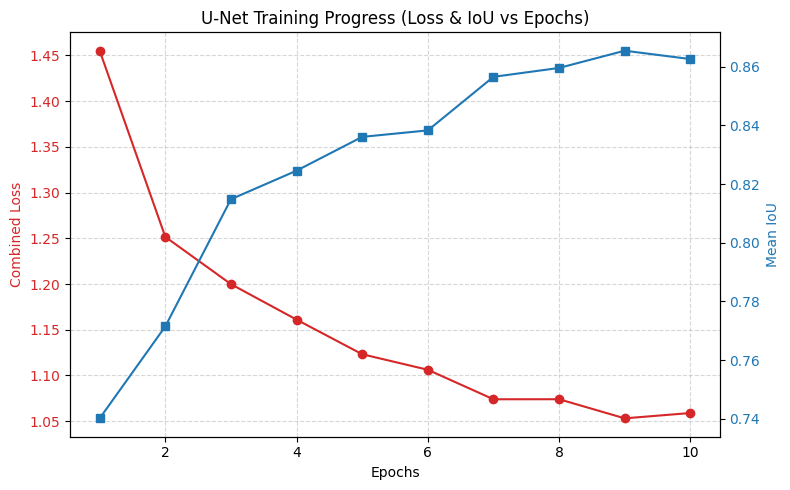

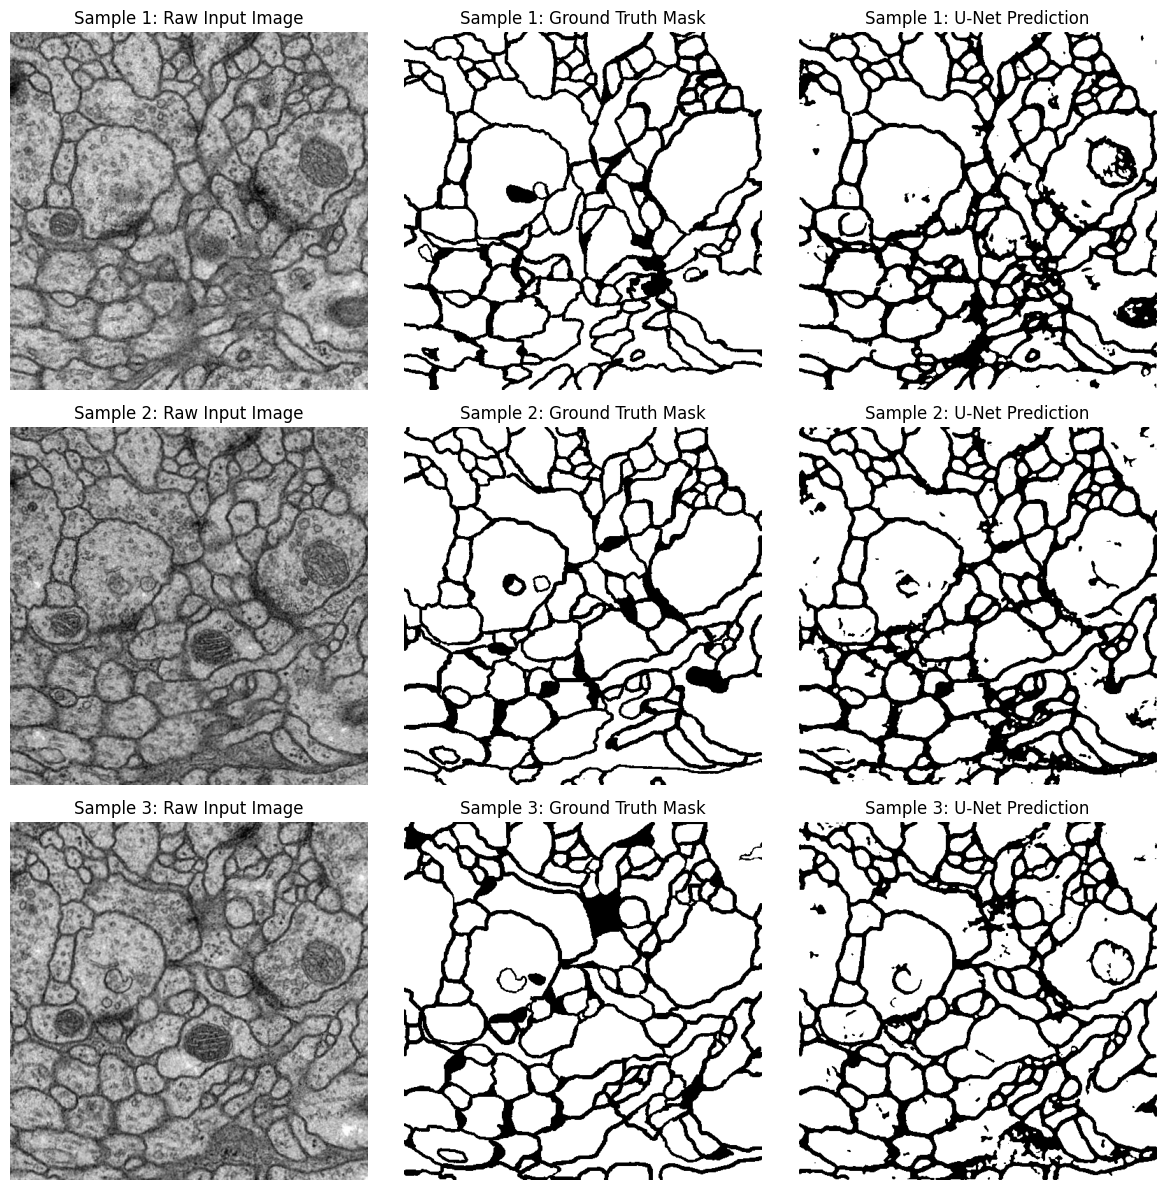

In [20]:

import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_training_history(history):
    """
    Plots training loss and mean IoU progress across epochs.
    """
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Combined Loss', color=color)
    ax1.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Mean IoU', color=color)
    ax2.plot(range(1, len(history['train_iou']) + 1), history['train_iou'], color=color, marker='s', label='Train IoU')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('U-Net Training Progress (Loss & IoU vs Epochs)')
    fig.tight_layout()
    plt.show()


def visualize_predictions(model, dataset, num_samples=3, device='cpu'):
    """
    Runs inference on sample images and displays a side-by-side comparison:
    Raw Input Image | Ground Truth Mask | Predicted Segmentation Mask
    """
    model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i in range(num_samples):
            image_tensor, mask_tensor, _ = dataset[i]

            input_tensor = image_tensor.unsqueeze(0).to(device)

            logits = model(input_tensor)

            probs = torch.sigmoid(logits)
            pred_mask = (probs > 0.5).float().cpu().squeeze().numpy()

            raw_img = image_tensor.squeeze().numpy()
            gt_mask = mask_tensor.squeeze().numpy()

            # Column 1: Raw Input Image
            axes[i, 0].imshow(raw_img, cmap='gray')
            axes[i, 0].set_title(f"Sample {i+1}: Raw Input Image")
            axes[i, 0].axis('off')

            # Column 2: Ground Truth Mask
            axes[i, 1].imshow(gt_mask, cmap='gray')
            axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask")
            axes[i, 1].axis('off')

            # Column 3: U-Net Prediction
            axes[i, 2].imshow(pred_mask, cmap='gray')
            axes[i, 2].set_title(f"Sample {i+1}: U-Net Prediction")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


plot_training_history(train_history)

eval_dataset = ISBI2012Dataset(IMAGE_PATH, MASK_PATH)
visualize_predictions(model, eval_dataset, num_samples=3, device=device)